In [2]:

def load_model_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_sum.pt"))

def load_R2SP_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "R2SP_client_sum.pt"))

def load_server_to_client_sum(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "sever_to_client_sum.pt"))

def load_client_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_loss.pt"))

def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        print(c[0] == 0)
        return c[1:]
    else:
        return c

def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))

def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))
    
def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))



            
            

def get_acc_time(acc,time):
    target_acc = [0.83]
    n = 10
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*3
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = int(cv_time[index])
                ac_time[i] = int(cv_time[index])
                i = i+1
    return ac_time



# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"

def plt_photo_acc(exp, exp_legend, fig_name='PR-FL', y_lim=[0.70, 0.90], x_lim=[1, 80000],acc = 'avg', cov = False):
    import matplotlib.pyplot as plt
    import os
    from os.path import join
    
    # Define the interval for markers
    interval = 10  # You can adjust this value to change the marker density
    # config2 = type("Config", (object,), {"EXP_NAME": "experiment_name"})  # 示例配置
    

    # Create a new figure
    figsize = (7, 5.25)
    plt.figure(figsize=figsize)
    ac_time = {}
    from matplotlib.ticker import FuncFormatter
    # Iterate through all experiments to plot each curve
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            acc = load_acc(exp_name)
            fed_avg_acc = load_fed_avg_acc(exp_name)
            time = load_time(exp_name)
            cv_acc = np.convolve(fed_avg_acc, np.ones((n,)) / n, mode='valid')
            cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
            if not cov: 
                cv_acc = fed_avg_acc
                
                cv_time = time
            at = get_acc_time(fed_avg_acc,time)
            ac_time[exp_legend[i]] = at

            plt.plot(cv_time, cv_acc, linestyle=linestyles[i % 5], color=colors[i%8], linewidth=1, label=exp_legend[i])
            mark_interval = interval * 2
            if 'fed_avg' in exp_name and 'mask_fed_avg' not in exp_name:
                mark_interval = int(interval / 2)
                
            plt.plot(cv_time[::mark_interval], cv_acc[::mark_interval], linestyle='None', marker=markers[i%8], color=colors[i%8])

        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    for key in ac_time.keys():
        print(key, ":", ac_time[key])
    # Set labels and axis limits
    plt.xlabel("Time ($10^4$ s)",fontsize=16)
    plt.ylabel("Test Accuracy",fontsize=16)
    plt.xticks(fontsize=14)  # 增大 x 轴刻度字体
    plt.yticks(fontsize=14)  # 增大 y 轴刻度字体
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    # 使用 FuncFormatter 应用自定义格式
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo))
    # Add legend
    plt.legend(
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0),
        fontsize= 'x-large',
        ncol=2
    )

    # Set grid
    plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

    # Ensure result directories exist and save the figure
    result_path = join("results", config.EXP_NAME)
    fig_path = join(result_path, "figs")

    if not os.path.isdir(fig_path):
        os.makedirs(fig_path)

    plt.savefig(join(fig_path, fig_name + ".png"), dpi=600, bbox_inches='tight')  # Save as PNG format
    plt.show()








%matplotlib inline
import matplotlib.pyplot as plt
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

dataset_name = "FEMNIST"
import configs.femnist as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 10

result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 5, 1, 5)), (0, (1, 10))]
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
markers = ['o', '*', 'D', 's','p', 'v', '^', 'x', 'h', 'H', '<', '>', 'd', '+', '1', '2', '3', '4']

In [3]:
# find the best model ratio of different stage

In [4]:
result_path = join("results", config.EXP_NAME,'Best_ratio2')
import os
list2 = os.listdir(result_path)
list2 = sorted(list2)
list2

FileNotFoundError: [Errno 2] No such file or directory: 'results/FEMNIST/Best_ratio2'

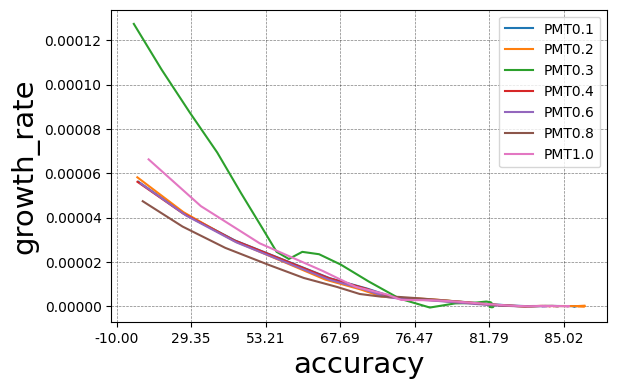

In [29]:
plt.figure()
list2 = [
# 'PMT0.025',
#  'PMT0.05',
 'PMT0.1',
 'PMT0.2',
 'PMT0.3',
 'PMT0.4',
 'PMT0.6',
 'PMT0.8',
 'PMT1.0',
]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import torch
full_time = load(join(result_path, "{}".format('PMT1.0'), "est_time.pt"))[0]
def conv(acc, n):
    new_acc = []
    n = int(n/2)
    if n > len(acc):
        print('list is too short')
    for i in range(len(acc)):
        if i == 0 or i == len(acc)-1:
            new_acc.append(acc[i])
        else:
            windows = min(i,n,len(acc)-1-i)
            new_acc.append(np.mean(acc[i-windows:i+windows+1]))
    new_acc = np.array(new_acc)
    return new_acc
                    
                           
            
n=5
interval = 10
final_density = 0.90
acc_list = []
time_list = []
label_list = []
for i in range(len(list2)):
    exp_name = list2[i]
    try:
        acc = load_fed_avg_acc(exp_name)
        acc = acc[:interval] + acc[interval:-interval:interval] +  acc[-interval:]
        acc = conv(acc, n)
        time = load_real_time(exp_name)
        time2 = float(load(join(result_path, "{}".format(exp_name), "est_time.pt"))[0])
        import re

        
        time =  time[:interval] + time[interval:-interval:interval] +  time[-interval:]
        time =  np.array([t.cpu().numpy() if torch.is_tensor(t) else t for t in time])
        
        smooth_acc = savgol_filter(acc, window_length=7, polyorder=2)
        # smooth_acc = acc
        growth_rate_smooth = np.gradient(acc, time)
        growth_rate_smooth = savgol_filter(growth_rate_smooth, window_length=7, polyorder=2)
        # === 可选：以准确率为横轴重建关系 ===
        # 注意 acc_dense 单调时才可以这么做，否则要做处理
        log_acc = -np.log(final_density-smooth_acc)
        plt.plot(log_acc[:-(n//2)], growth_rate_smooth[:-(n//2)],  label=exp_name, )
        # plt.plot(time, smooth_acc,  label=exp_name, )
        acc_list.append(log_acc),time_list.append(growth_rate_smooth), label_list.append(exp_name)

    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")


# plt.ylim([-0.0000025,0.00001])
plt.xlabel('accuracy', fontsize=21)
plt.ylabel("growth_rate", fontsize=21)
# plt.legend(list2,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
# def format_kilo3(x, _):
#     return f"{((final_density - np.exp(-x))*100):.2f}"
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo3))
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def linear_between_neighbors(x_raw, y_raw, x_target):
    x_raw = np.asarray(x_raw)
    y_raw = np.asarray(y_raw)
    sort_idx = np.argsort(x_raw)
    x_sorted = x_raw[sort_idx]
    y_sorted = y_raw[sort_idx]
    result = np.full_like(x_target, np.nan, dtype=np.float64)
    for i, xt in enumerate(x_target):
        idx = np.searchsorted(x_sorted, xt)
        if 0 < idx < len(x_sorted):
            x0, x1 = x_sorted[idx - 1], x_sorted[idx]
            y0, y1 = y_sorted[idx - 1], y_sorted[idx]
            t = (xt - x0) / (x1 - x0)
            result[i] = (1 - t) * y0 + t * y1
        else:
            result[i] = -0.00001
    return result

def plot_max_segment_lines(x_list, y_list, label_list):
    num_lines = len(x_list)

    # 统一采样 x
    xmin = max([min(x) for x in x_list])
    xmax = max([max(x) for x in x_list])
    x_uniform = np.linspace(xmin, xmax, 300)

    # 插值
    y_interp_all = []
    for xk, yk in zip(x_list, y_list):
        y_interp = linear_between_neighbors(xk, yk, x_uniform)
        y_interp_all.append(y_interp)
    y_interp_all = np.array(y_interp_all)  # shape: (num_lines, len(x_uniform))

    # 准备颜色
    colors = plt.cm.tab10(np.linspace(0, 1, num_lines))

    fig, ax = plt.subplots()

    # 分段画图
    for i in range(len(x_uniform) - 1):
        x_seg = [x_uniform[i], x_uniform[i+1]]
    
        y_start = y_interp_all[:, i]
        y_end = y_interp_all[:, i+1]
    
        # 对这一段的平均 y 排序（更稳）
        y_avg = (y_start + y_end) / 2
        if np.all(np.isnan(y_avg)):
            continue
    
        max_idx = np.nanargmax(y_avg)
    
        for k in range(num_lines):
            y_seg = [y_interp_all[k, i], y_interp_all[k, i+1]]
            if np.any(np.isnan(y_seg)):
                continue

            linestyle = '-' if k == max_idx else (0, (10, 6))
            ax.plot(x_seg, y_seg, color=colors[k], linestyle=linestyle, linewidth=1.5)



    # 添加自定义图例（因为每条线是分段绘制的，正常 plot 无法生成完整图例）
    legend_lines = [
        Line2D([0], [0], color=colors[k], linestyle='-', linewidth=2, label=label_list[k])
        for k in range(num_lines)
    ]
    ax.legend(handles=legend_lines)

    ax.set_xlabel("growth rate")
    ax.set_ylabel("accuracy")
    def format_kilo3(x, _):
        return f"{((final_density - np.exp(-x))*100):.2f}"
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo3))
    # ax.set_title("Only Max Line is Solid Per Segment")
    plt.grid(True)
    plt.show()


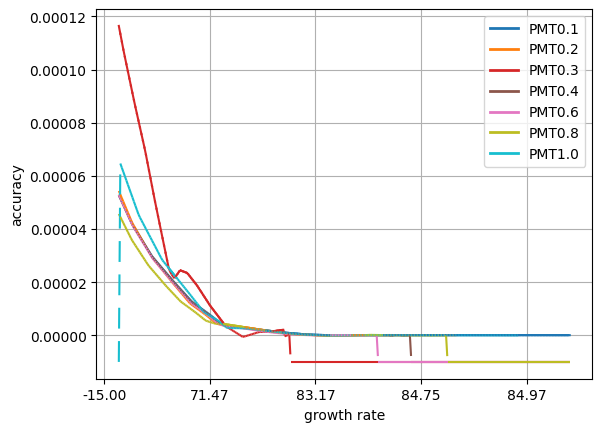

In [25]:
x_list = acc_list
y_list = time_list
label_list
plot_max_segment_lines(x_list, y_list, label_list)



In [102]:
result_path = join("results", config.EXP_NAME,'Best_ratio')
import os
list2 = os.listdir(result_path)
list2 = sorted(list2)
list2


['PMT0.025',
 'PMT0.05',
 'PMT0.1',
 'PMT0.2',
 'PMT0.3',
 'PMT0.4',
 'PMT0.6',
 'PMT0.8',
 'PMT1.0']

In [1]:
plt.figure()
list2 = [
    'PMT0.025',
    'PMT0.05',

    'PMT0.3',
    'PMT0.4',
    'PMT0.6',
    'PMT0.8',
 'PMT1.0'

]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
n=10
for i in range(len(list2)):
    exp_name = list2[i]
    try:
        acc = load_fed_avg_acc(exp_name)
        acc = acc[:interval] + acc[interval:-interval:interval] +  acc[-interval:]
        acc = conv(acc, n)
        time = load_real_time(exp_name)
        time =  time[:interval] + time[interval:-interval:interval] +  time[-interval:]
        time =  [t.cpu().numpy() if torch.is_tensor(t) else t for t in time]
        time = conv(time, n)
        smooth_acc = savgol_filter(acc, window_length=7, polyorder=2)
        growth_rate_smooth = np.gradient(smooth_acc, time)
        growth_rate_smooth = savgol_filter(growth_rate_smooth, window_length=7, polyorder=2)
        # === 可选：以准确率为横轴重建关系 ===
        # 注意 acc_dense 单调时才可以这么做，否则要做处理
        log_acc = -np.log(0.85-smooth_acc)


        plt.plot(log_acc, growth_rate_smooth,  label=exp_name, )
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")

# plt.xlabel(r"Round (s)")
# plt.ylabel("Sub_Fedavg server Acc")
# # plt.xlim([1,7000])
plt.ylim([-0.0000025,0.00001])

# plt.legend(list2,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(True)  # Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
def format_kilo3(x, _):
    return f"{((0.85 - np.exp(-x))*100):.2f}"
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo3))
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


NameError: name 'plt' is not defined

In [32]:
import os
list = os.listdir(result_path)
list = sorted(list)


In [242]:
def get_time_acc(acc,time,time_line):
    windows = 5
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)


    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100
    f_mean = np.mean(acc[-1-windows:-1])*100
    f_std = np.std(acc[-1-windows:-1])*100

    cv_acc = np.convolve(acc, np.ones((windows,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((windows,)) / n, mode='valid')

    for t,a in zip(cv_time,cv_acc):
        if a >= f_mean:
            break
                    

    return [round(b_mean, 2),f"{b_std:.2g}",t]

def plt_time_acc(exp, time_line):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            time = load_time(exp_name)
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    for key in time_acc.keys():
        print(f"{key}: {time_acc[key]}")

In [243]:
exp2 = [
'niid_medium__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_medium__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_medium__1.0_10_fed_asyn_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_medium__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
]
plt_time_acc(exp2,120000)

niid_medium__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25: [84.72, '0.22', 110612.6167460188]
niid_medium__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25: [79.07, '0.76', 609292.3449331796]
niid_medium__1.0_10_fed_asyn_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25: [83.45, '0.3', 94556.22934297448]
Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25: [83.9, '0.25', 104677.95850417059]


In [234]:

exp2 = [
'Ablation_[1, 0.2]_NoRe',
 'Ablation_[1, 0.2]_RE',
 'Ablation_[1, 0.5, 0.2, 0.1, 0.05]_NoRe',
 'Ablation_[1, 0.5, 0.2, 0.1, 0.05]_RE',
]
plt_time_acc(exp2,15000)



Ablation_[1, 0.2]_NoRe: [80.09, '0.64', 49697.32276070726]
Ablation_[1, 0.2]_RE: [80.84, '0.22', 49778.99952616219]
Ablation_[1, 0.5, 0.2, 0.1, 0.05]_NoRe: [76.82, '0.54', 9579.317932554393]
Ablation_[1, 0.5, 0.2, 0.1, 0.05]_RE: [78.32, '0.38', 9764.34291623645]


In [235]:

exp2 = [
'Ablation_[1, 0.2]_NoRe',
 'Ablation_[1, 0.2]_RE',
 'Ablation_[1, 0.5, 0.2, 0.1, 0.05]_NoRe',
 'Ablation_[1, 0.5, 0.2, 0.1, 0.05]_RE',
]
plt_time_acc(exp2,10000)


Ablation_[1, 0.2]_NoRe: [77.76, '0.44', 49697.32276070726]
Ablation_[1, 0.2]_RE: [78.32, '0.53', 49778.99952616219]
Ablation_[1, 0.5, 0.2, 0.1, 0.05]_NoRe: [73.66, '1', 9579.317932554393]
Ablation_[1, 0.5, 0.2, 0.1, 0.05]_RE: [76.05, '0.54', 9764.34291623645]


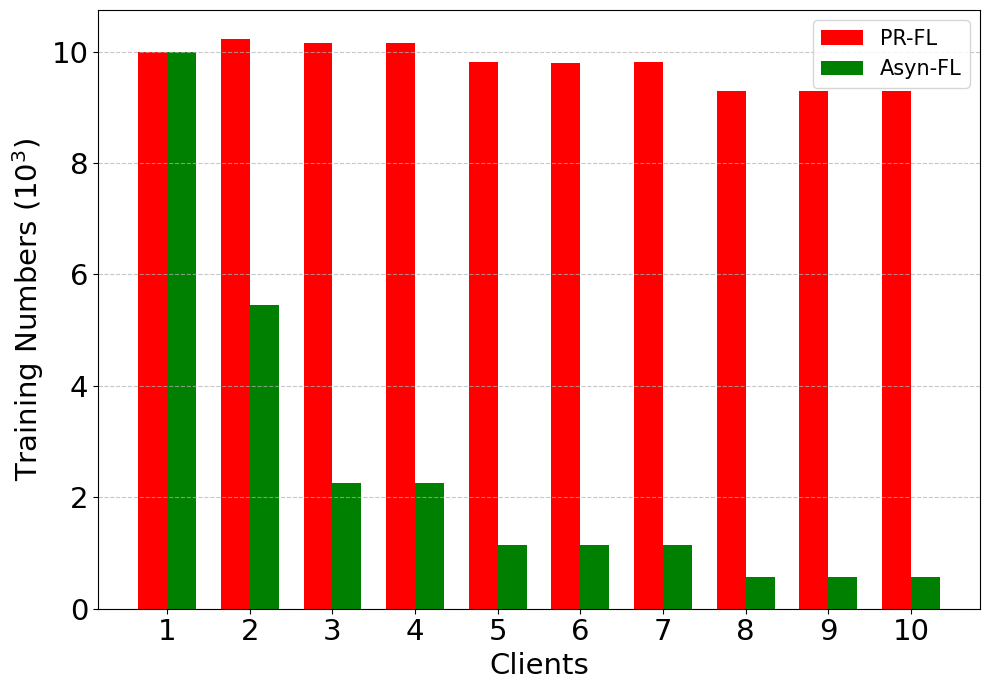

In [236]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
clients = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
fedasyn = [10000, 5445, 2263, 2260, 1143, 1143, 1143, 575, 575, 576]
pr_fl = [10000, 10236, 10162, 10151, 9818, 9804, 9819, 9286, 9286, 9294]

# 设置柱状图参数
x = np.arange(len(clients))  # 客户端编号的位置
width = 0.35  # 柱状图的宽度

# 绘制图表
plt.figure(figsize=(10, 7))
plt.bar(x - width/2, pr_fl, width, label='PR-FL', color='red')
plt.bar(x + width/2, fedasyn, width, label='Asyn-FL', color='green')


# 添加标签和标题
plt.xlabel('Clients', fontsize=21)
plt.ylabel("Training Numbers ($10^3$)", fontsize=21)
"Time ($10^4$ s)"
# plt.title('Comparison of Training Numbers for FedAsyn and PR-FL', fontsize=14)
plt.xticks(x, clients)
plt.legend(fontsize=15)

plt.xticks(fontsize=21)  # 增大 x 轴刻度字体
plt.yticks(fontsize=21)  # 增大 y 轴刻度字体
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_kilo2))
# 显示图表
plt.tight_layout()

result_path = join("results", config.EXP_NAME)
fig_path = join(result_path, "figs")

if not os.path.isdir(fig_path):
    os.makedirs(fig_path)
plt.savefig(join(fig_path, 'Training numbers' + ".png"), dpi=300) 
plt.show()

In [237]:
# acc vs time

In [238]:
 'Resiid_low__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resiid_medium__1.0_10_fed_asyn_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resiid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_high__1.0_10_fed_asyn_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_high__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_low__1.0_10_fed_asyn_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_low__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',

('Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25',)

True
True
True
True
PR-FL : [34825, None, None]
Syn-FL : [280011, None, None]
Asyn-FL : [79240, None, None]
Sub_FL : [41340, None, None]


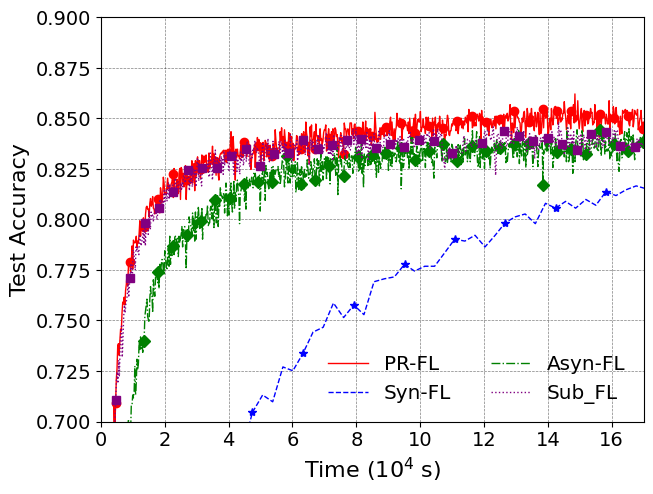

True
True
True
True
PR-FL : [42185, None, None]
Syn-FL : [284266, None, None]
Asyn-FL : [96632, None, None]
Sub_FL : [52713, None, None]


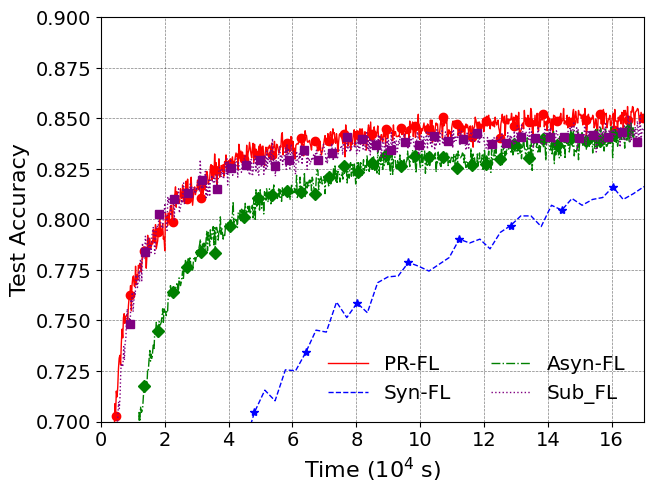

True
True
True
True
PR-FL : [48886, None, None]
Syn-FL : [290905, None, None]
Asyn-FL : [176951, None, None]
Sub_FL : [111592, None, None]


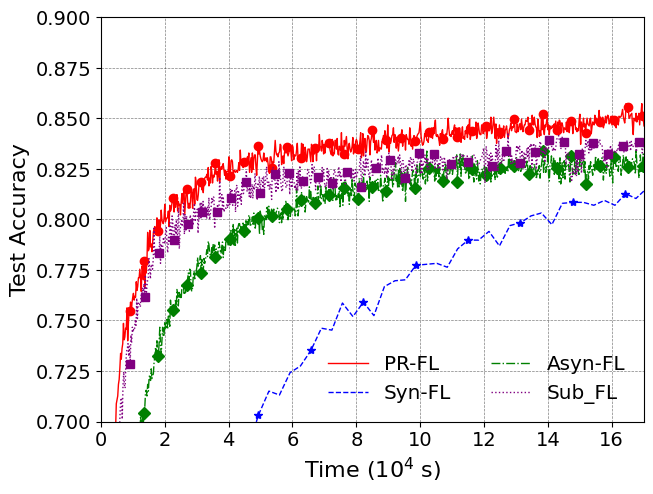

In [244]:
exp1 = [
    # 'patience10niidlow_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
'niid_low__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_low__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_low__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_low__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_low__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25'


]



exp_legend = [   
     # 'patience_10,PR-FL',
    'PR-FL',
    'Syn-FL',
    'Asyn-FL',
    # 'Sub-FL',
    'Sub_FL'
]



exp2 = [
'niid_medium__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_medium__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_medium__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_medium__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
]

exp3 = [
'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_high__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_high__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_high__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_high__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25'

]


fig_name_list = ['low_niid','medium_niid','high_niid']
exp_list = [exp1,exp2,exp3]
for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,170000])


    


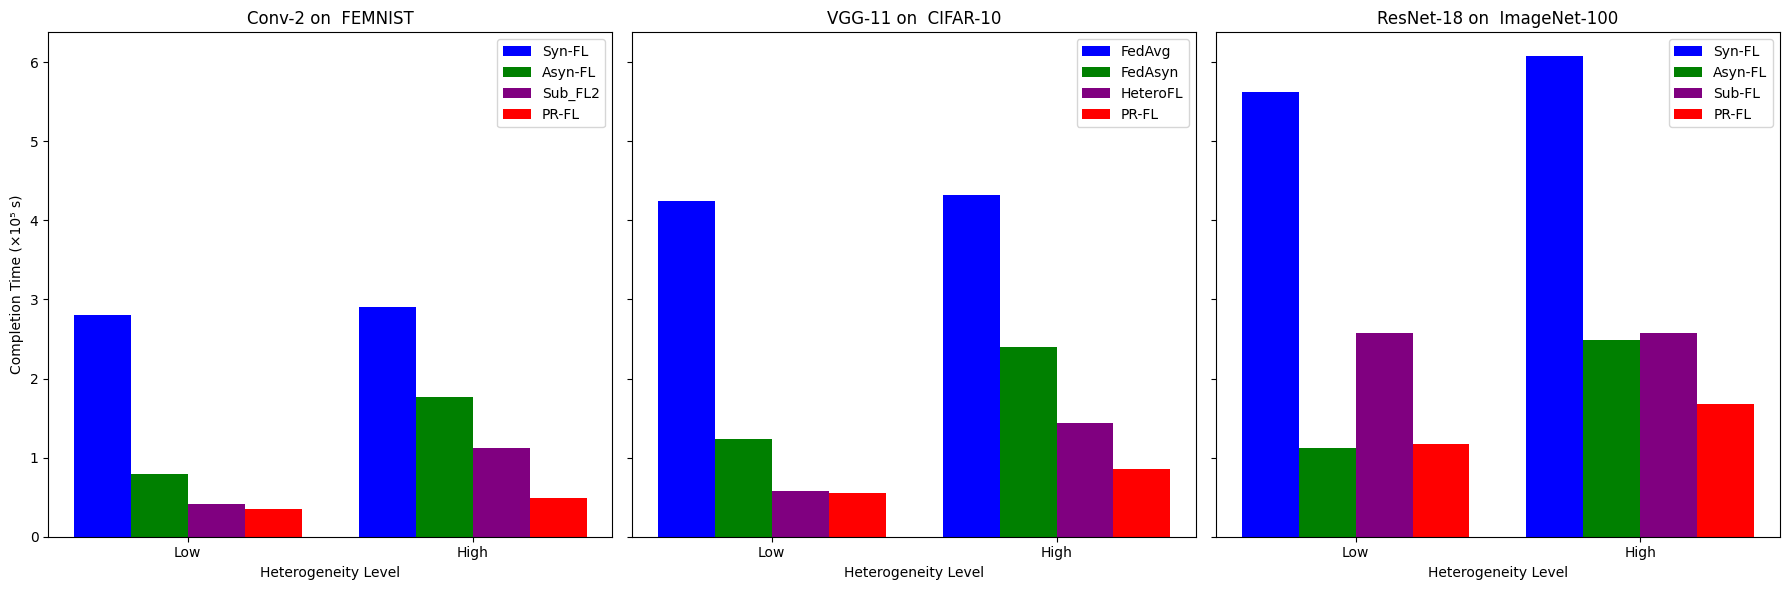

In [222]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the three datasets (Low and High only)
categories = ["Low", "High"]

# Dataset 1
data1 = {
    "Syn-FL": [280011, 290905],
    "Asyn-FL": [79240, 176951],
    "Sub_FL2": [41340, 111592],
    "PR-FL": [34825, 48886],
}

# Dataset 2
data2 = {
    "FedAvg": [424493.14250093186, 431385.1177750103],
    "FedAsyn": [123087.60298831633, 239627.57400173138],
    "HeteroFL": [57685.553943287654, 143136.5345742409],
    "PR-FL": [55849.72893487416, 85139.09003240851],
}

# Dataset 3 (Corrected Order)
data3 = {
    "Syn-FL": [562222.1971231233, 607234.228057792],
    "Asyn-FL": [112434.38299181251, 248157.82061116394],
    "Sub-FL": [257924.10039958055, 257310.19041490296],
    "PR-FL": [116635.24189392442, 167992.96003642405],
}
title = [
    'Conv-2 on  FEMNIST',
    'VGG-11 on  CIFAR-10',
    'ResNet-18 on  ImageNet-100',
]
color = [ 'blue', 'green', 'purple','red',]
# Convert data to 10^5 scale for better visualization
datasets = [data1, data2, data3]
datasets_scaled = [
    {key: [val / 1e5 for val in values] for key, values in dataset.items()}
    for dataset in datasets
]

# Plotting the bar charts for each dataset
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (data_scaled, ax) in enumerate(zip(datasets_scaled, axs)):
    x = np.arange(len(categories))  # the label locations
    width = 0.2  # the width of the bars

    # Plot each method as a bar
    for j, (method, values) in enumerate(data_scaled.items()):
        ax.bar(x + j * width, values, width, label=method,color = color[j])

    # Add labels, title, and custom x-axis tick labels
    ax.set_xlabel("Heterogeneity Level")
    ax.set_title(title[i])
    ax.set_xticks(x + width * (len(data_scaled) - 1) / 2)
    ax.set_xticklabels(categories)
    if i == 0:
        ax.set_ylabel("Completion Time (×10⁵ s)")
    ax.legend()
    
plt.savefig(join(fig_path, 'hetero' + ".png"), dpi=300)  # Save as PNG format
# Adjust layout and display
plt.tight_layout()
plt.show()


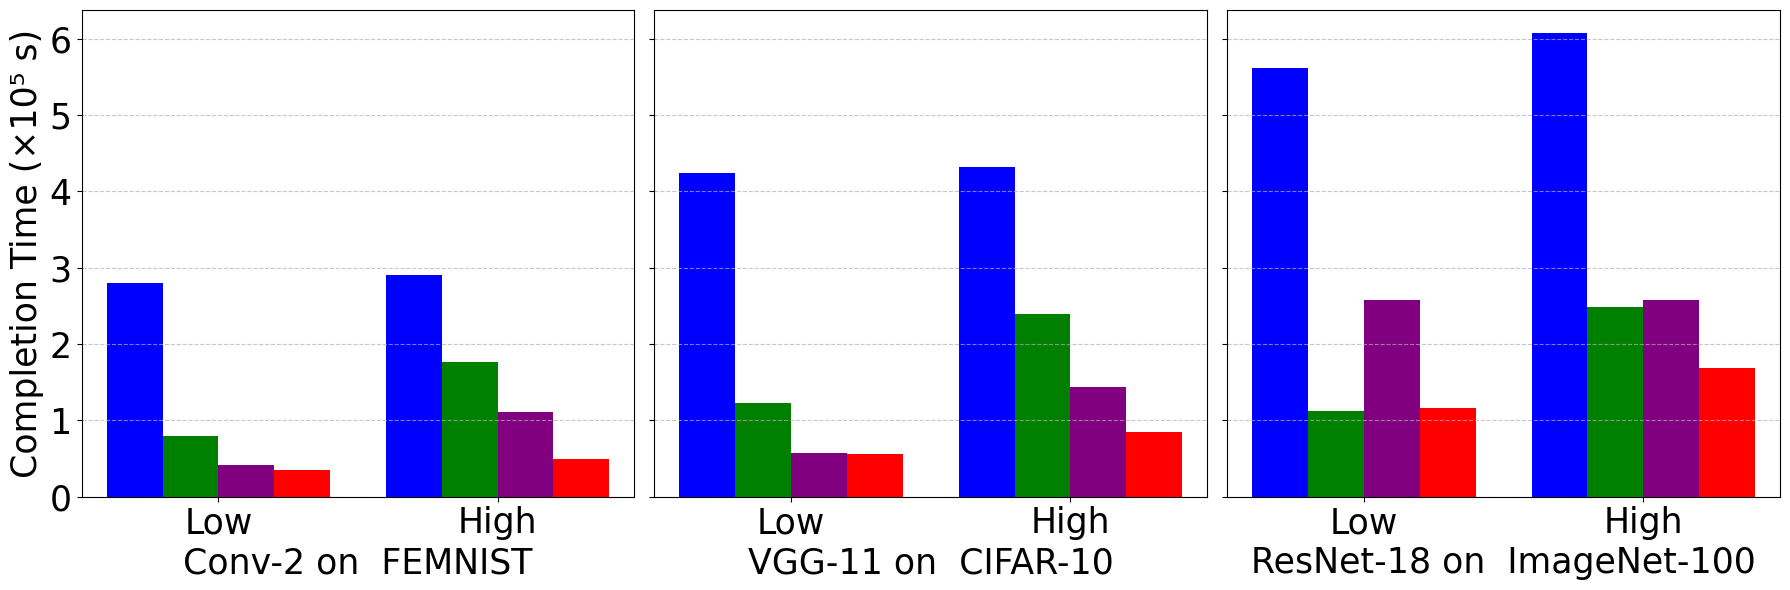

In [226]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the three datasets (Low and High only)
categories = ["Low", "High"]

# Dataset 1
data1 = {
    "Syn-FL": [280011, 290905],
    "Asyn-FL": [79240, 176951],
    "Sub_FL2": [41340, 111592],
    "PR-FL": [34825, 48886],
}

# Dataset 2
data2 = {
    "FedAvg": [424493.14250093186, 431385.1177750103],
    "FedAsyn": [123087.60298831633, 239627.57400173138],
    "HeteroFL": [57685.553943287654, 143136.5345742409],
    "PR-FL": [55849.72893487416, 85139.09003240851],
}

# Dataset 3 (Corrected Order)
data3 = {
    "Syn-FL": [562222.1971231233, 607234.228057792],
    "Asyn-FL": [112434.38299181251, 248157.82061116394],
    "Sub-FL": [257924.10039958055, 257310.19041490296],
    "PR-FL": [116635.24189392442, 167992.96003642405],
}

# Convert data to 10^5 scale for better visualization
datasets = [data1, data2, data3]
datasets_scaled = [
    {key: [val / 1e5 for val in values] for key, values in dataset.items()}
    for dataset in datasets
]

# Plotting the bar charts for each dataset
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (data_scaled, ax) in enumerate(zip(datasets_scaled, axs)):
    x = np.arange(len(categories))  # the label locations
    width = 0.2  # the width of the bars

    # Plot each method as a bar
    for j, (method, values) in enumerate(data_scaled.items()):
        ax.bar(x + j * width, values, width, label=method,color = color[j])

    # Add labels, title, and custom x-axis tick labels
    ax.set_xlabel(title[i], fontsize=25)
    # ax.set_title(title[i])
    ax.set_xticks(x + width * (len(data_scaled) - 1) / 2)
    ax.set_xticklabels(categories, fontsize=20)
    if i == 0:
        ax.set_ylabel("Completion Time (×10⁵ s)", fontsize=25)

    # Customize ticks and grid
    ax.tick_params(axis='x', labelsize=25)  # x-axis font size
    ax.tick_params(axis='y', labelsize=25)  # y-axis font size
    ax.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines
# Adjust layout and display
plt.tight_layout()
    # Add legend
    # ax.legend(fontsize=15)
plt.savefig(join(fig_path, 'hetero.png'), dpi=600, bbox_inches='tight')

plt.show()


In [196]:
def get_acc_time(acc,time,acc_line):
    windows = 10
    cv_acc = np.convolve(acc, np.ones((windows,)) / windows, mode='valid')
    cv_time = np.convolve(time, np.ones((windows,)) / windows, mode='valid')

    for t,a in zip(cv_time,cv_acc):
        if a >= acc_line and a <= acc_line + 0.0002:
            break
                    

    return t

def get_time_c(time,acc,time_line):
    windows = 10
    cv_acc = np.convolve(acc, np.ones((windows,)) / windows, mode='valid')
    cv_time = np.convolve(time, np.ones((windows,)) / windows, mode='valid')
    for index, T in enumerate(time):
        if T>time_line :
            break;
    b_mean = acc[index]
                    

    return b_mean

In [197]:
exp1 = [
    # 'patience10niidlow_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
'niid_low__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_low__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_low__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_low__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_low__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25'


]



exp_legend = [   
     # 'patience_10,PR-FL',
    'PR-FL',
    'Syn-FL',
    'Asyn-FL',
    # 'Sub-FL',
    'Sub_FL2'
]



exp2 = [
'niid_medium__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_medium__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_medium__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_medium__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'Resniid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
]

exp3 = [
'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'niid_high__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_high__1.0_10_fed_asyn_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'niid_high__1.0_10_heterofl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resniid_high__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25'

]


fig_name_list = ['low_niid','medium_niid','high_niid']
exp_list = [exp1,exp2,exp3]

for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    acc_lime = 0.835
    time_line = None
    acc_list = []
    for ex in exp:
        fed_avg_acc = load_fed_avg_acc(ex)
        time = load_time(ex)
        if 'pr' in ex:
            time_line = get_acc_time(fed_avg_acc,time,acc_lime)
        acc = get_time_c(time,fed_avg_acc,time_line)
        acc_list.append(acc)
    print(time_line,acc_list)

    


40398.181225519416 [0.8366858237547893, 0.6848659003831418, 0.8136973180076629, 0.8304597701149425]
54019.727945786544 [0.835727969348659, 0.7102490421455939, 0.8170498084291188, 0.8314176245210728]
67859.1089675374 [0.8333333333333334, 0.7461685823754789, 0.8165708812260536, 0.8208812260536399]


True
True
True
True
PR-FL : [23222, 51785, 83483]
Syn-FL : [184472, 287504, 345387]
Asyn-FL : [56026, 109789, 147280]
Sub-FL : [24880, 53165, 76998]


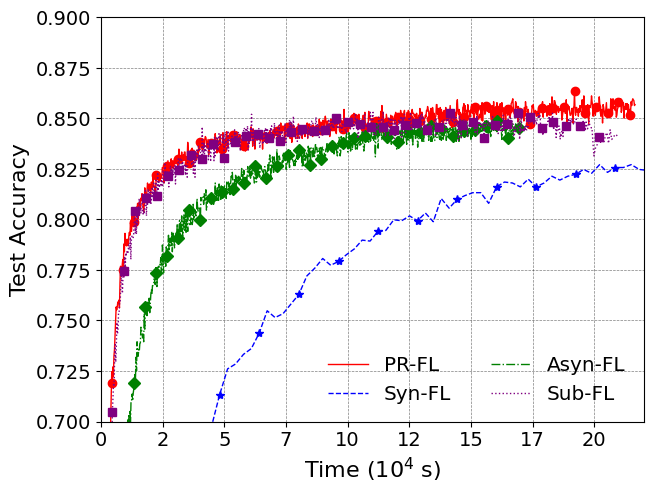

In [149]:


exp_legend = [   
     # 'patience_10,PR-FL',
    'PR-FL',
    'Syn-FL',
    'Asyn-FL',
    'Sub-FL',
        'Sub-FL2',
]



exp2 = [
'iid_medium__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'iid_medium__1.0_10_fed_avg_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'iid_medium__1.0_10_fed_asyn_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Resiid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
# 'Resiid_medium__1.0_10_heterofl_FEMNIST_0.5_10_[0.5, 0.2, 0.1, 0.05]__25'
]




fig_name_list = ['medium_iid']
exp_list = [exp2]

for i in range(len(exp_list)):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,220000])

    


In [57]:
#GMR on client heterogeneity

In [58]:
#with BaseLine

In [59]:
# With IID

In [60]:
#patience with GMR

True
True
True
patience=5 : [33709, 63396, 99306]
patience=10 : [29918, 40398, 89951]
patience=15 : [27690, 34378, 68975]


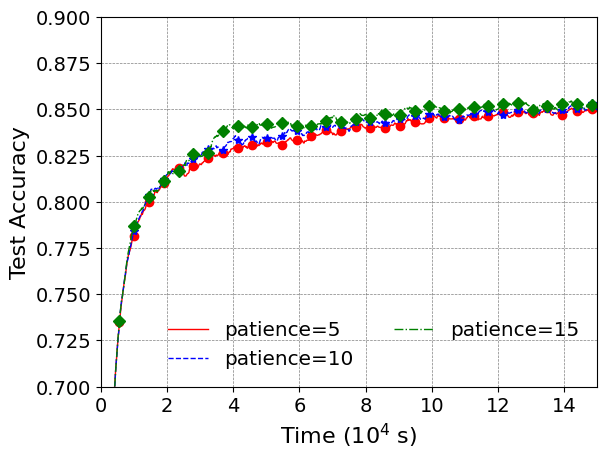

True
True
True
patience=5 : [48439, 77234, 121164]
patience=10 : [33263, 57593, 103994]
patience=15 : [37946, 53349, 98416]


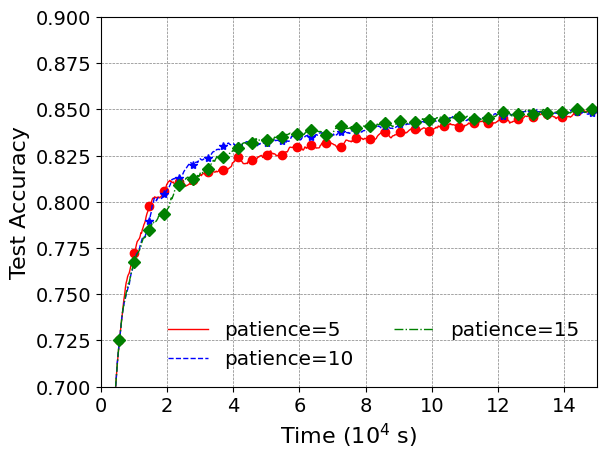

True
True
True
patience=5 : [55580, 98861, 139023]
patience=10 : [40174, 67859, 122057]
patience=15 : [47766, 61836, 120051]


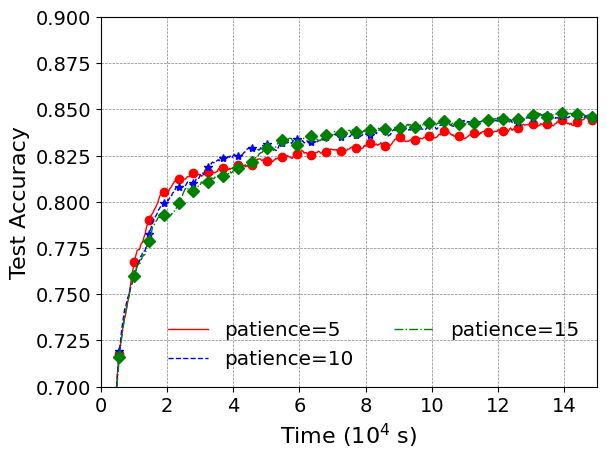

In [116]:
exp1 = [
 'niid_low__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_low__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_low__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
]



exp_legend = [   
     'patience=5',
    'patience=10',
     'patience=15',

]



exp2 = [
     'niid_medium__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_medium__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_medium__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

]

exp3 = [
 'niid_high__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

]


fig_name_list = ['low_niid','medium_niid','high_niid']
exp_list = [exp1,exp2,exp3]
for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,150000],cov = True)


In [ ]:
# split model
[0.467911877394636, 0.6954022988505747, 0.7772988505747126, 0.8151340996168582, 0.8271072796934866, 0.8309386973180076, 0.8314176245210728, 0.8314176245210728, 0.8314176245210728, 0.8314176245210728]



In [59]:
# Ablation Experiment

True
True
True
True
True
PR-FL : [13612, 40398, 89951]
-GMR : [17717, 76575, None]
-Asyn : [13046, 100506, 197978]
-Buff : [13433, 79052, 150093]
-MaskFedAvg : [24942, 126154, None]


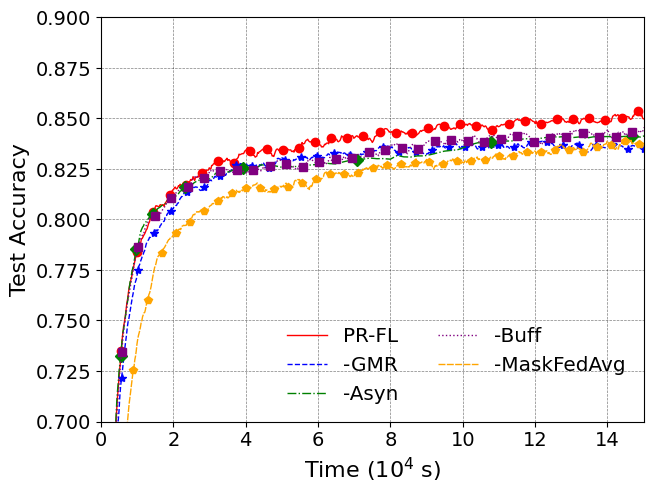

True
True
True
True
True
PR-FL : [17632, 61836, 102430]
-GMR : [21655, 102206, 214203]
-Asyn : [18388, 99619, 253312]
-Buff : [16067, 91737, 156643]
-MaskFedAvg : [38304, 169977, None]


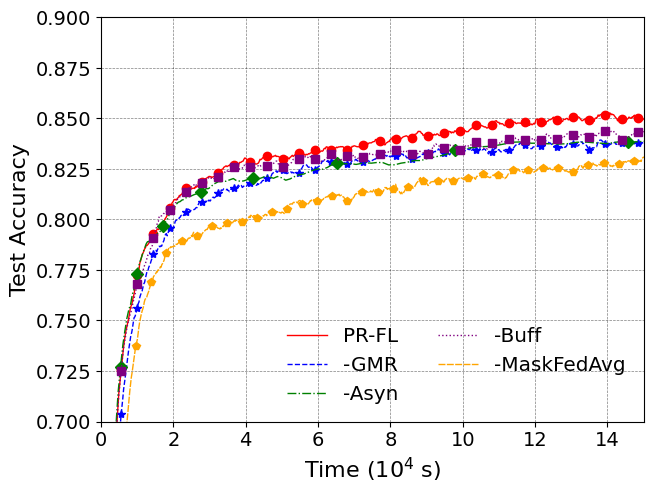

True
True
True
True
True
PR-FL : [19417, 67859, 122057]
-GMR : [31256, None, None]
-Asyn : [22030, 67286, 123441]
-Buff : [21207, 124067, None]
-MaskFedAvg : [28360, None, None]


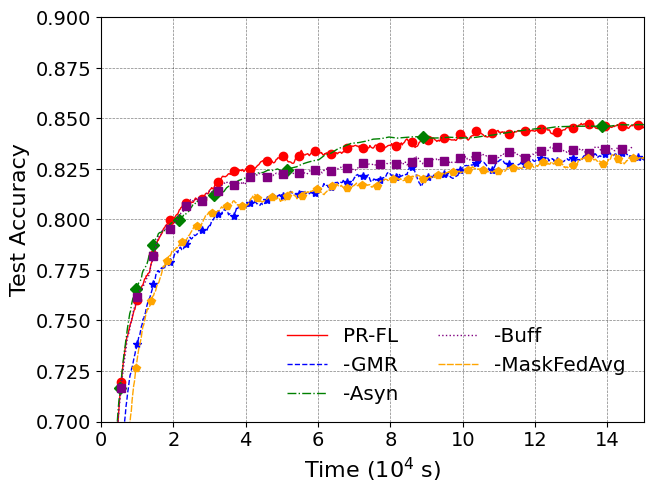

In [98]:


exp1 = [
'niid_low__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',      
'Ablation_niid_low__1.0_10_gmr_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_low__1.0_10_asyn_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_low__1.0_10_buff_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_low__1.0_10_mask_fed_avg_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
    ]

exp2 = [
 'Ablation_niid_medium__1.0_10_pr_fl_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
'Ablation_niid_medium__1.0_10_gmr_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_medium__1.0_10_asyn_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_medium__1.0_10_buff_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_medium__1.0_10_mask_fed_avg_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
]

exp3= [
'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
'Ablation_niid_high__1.0_10_gmr_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_high__1.0_10_asyn_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_high__1.0_10_buff_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
 'Ablation_niid_high__1.0_10_mask_fed_avg_FEMNIST_10_[1, 0.5, 0.2, 0.1, 0.05]__25',
]



exp_legend = [    
'PR-FL',   
'-GMR',
'-Asyn',
'-Buff',
'-MaskFedAvg',
]
fig_name_list = ['Fe_low_Ablation','Fe_medium_Ablation','Fe_high_Ablation']
exp_list = [exp1,exp2,exp3]
for i in range(3):
    exp = exp_list[i]
    fn = fig_name_list[i]
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.70,0.90],x_lim= [0,150000],cov = True)
    


Skipping high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25. Client selection = False.
Skipping high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25. Client selection = False.


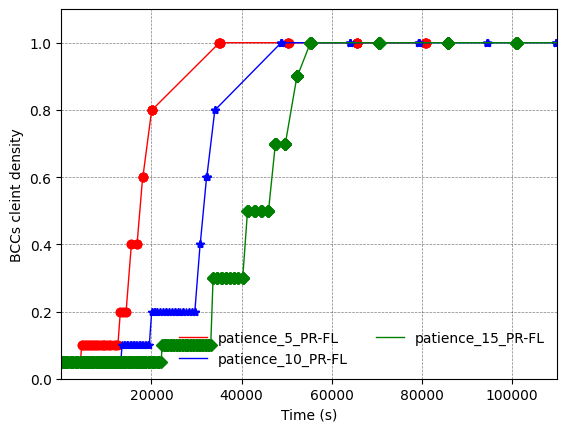

In [89]:
exp1 = [
     'niid_high__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
 'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
]



exp_legend = [   
         'patience_5_PR-FL',
     'patience_10_PR-FL',
     'patience_15_PR-FL',

    'FedAsyn',
    'HeteroFL',
]

# exp2 = [
# 'patience10medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25']

# exp3 = [
#     'patience10high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',]

for exp in[exp1]:
    plt_photo_density(exp,exp_legend,y_lim=[0,1.1])

1


/tmp/ipykernel_593255/3733655727.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


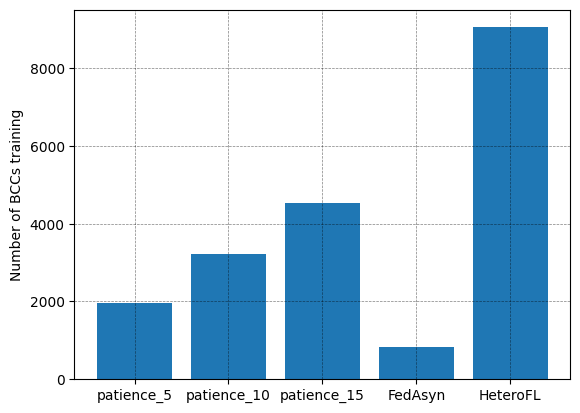

In [95]:
exp1 = [
     'niid_high__1.0_10_pr_fl_FEMNIST_5_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_10_[1.0, 0.5, 0.2, 0.1, 0.05]__25',
 'niid_high__1.0_10_pr_fl_FEMNIST_15_[1.0, 0.5, 0.2, 0.1, 0.05]__25',

'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
 'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
]



exp_legend = [   
         'patience_5',
     'patience_10',
     'patience_15',

    'FedAsyn',
    'HeteroFL',
]

# exp2 = [
# 'patience10medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'medium_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'medium_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25']

# exp3 = [
#     'patience10high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#     'high_mbuff_mask_fed_avg_asyn_0.02_Re_niid_1.0_10_Res_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfed_avg_syn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mfedasyn_asyn_1.0_Re_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',
#  'high_mheterofl_syn_0.02_NoRe_niid_1.0_10_NoRes_PR_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_poly_25',]

for exp in[exp1]:
    print('1')
    plt_photo_client_train_number(exp,exp_legend)

In [55]:
exp = [ 'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_fed_avg_g_0.0_0.0',
       'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_30_no_increase_-1.0_sub_fed_avg_g_0.0_0.0',
       'Hetero_FL——[Hetero_fair_cuda20000_lrdecay_finetune1000]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_R2SP_g_0.0_0.0',
       

      
      ]
exp_legend = [ 'fed_avg',
             'sub_fed_avg',
             'R2SP']


<IPython.core.display.Javascript object>


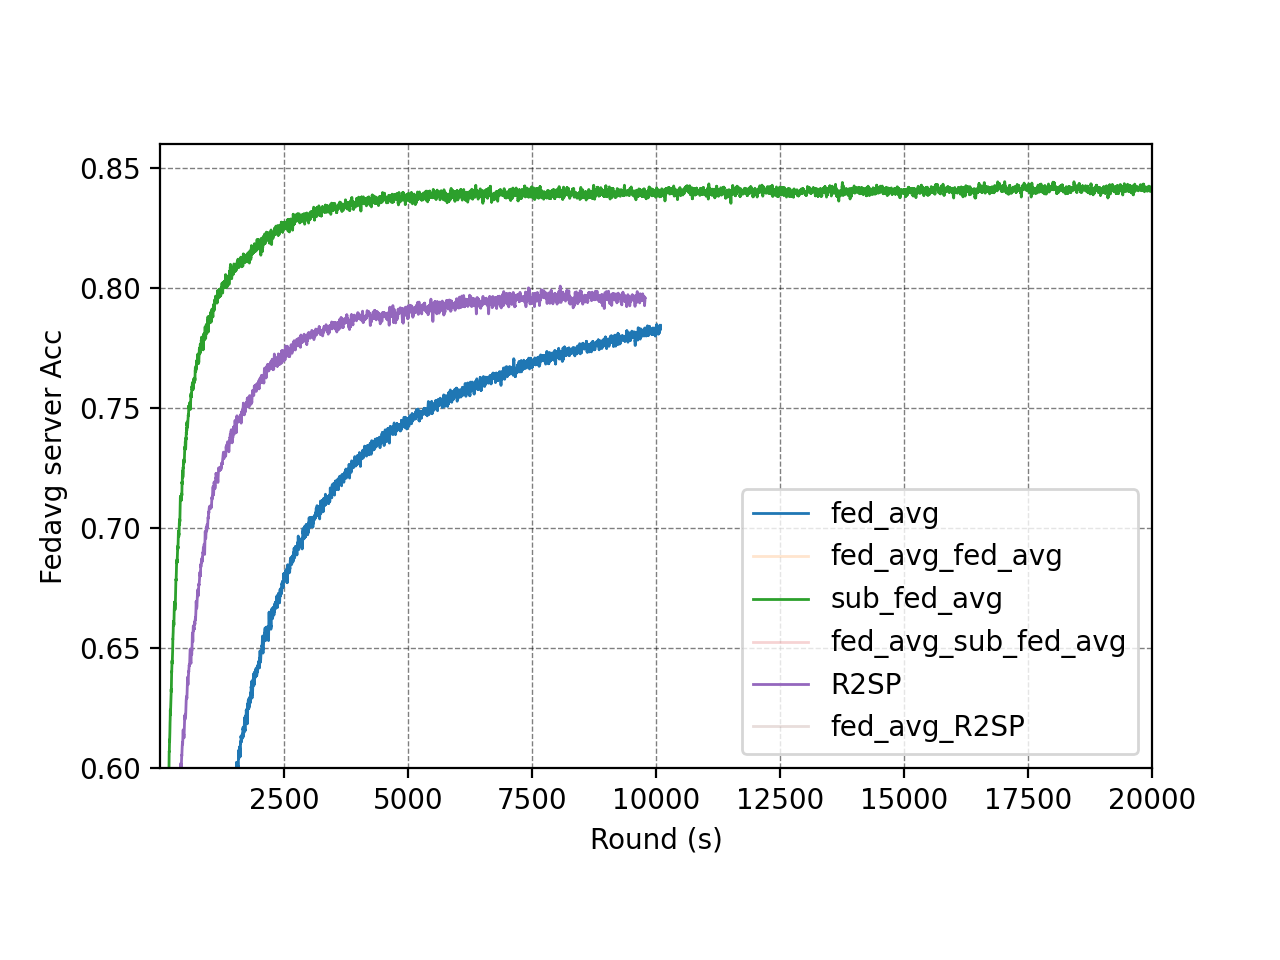

In [58]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


In [66]:
exp = [
     'Hetero_FL——[Hetero_fair_cuda20000_smalltobig]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_sub_fed_avg_g_0.0_0.1',
'Hetero_FL——[Hetero_fair_cuda20000_bigtosmall]_[1, 0.5, 0.1]un_fair_1.0_1_no_increase_-1.0_sub_fed_avg_g_0.0_0.1']


exp_legend = ['1,1,1',
              '1,1,1',

]




<IPython.core.display.Javascript object>


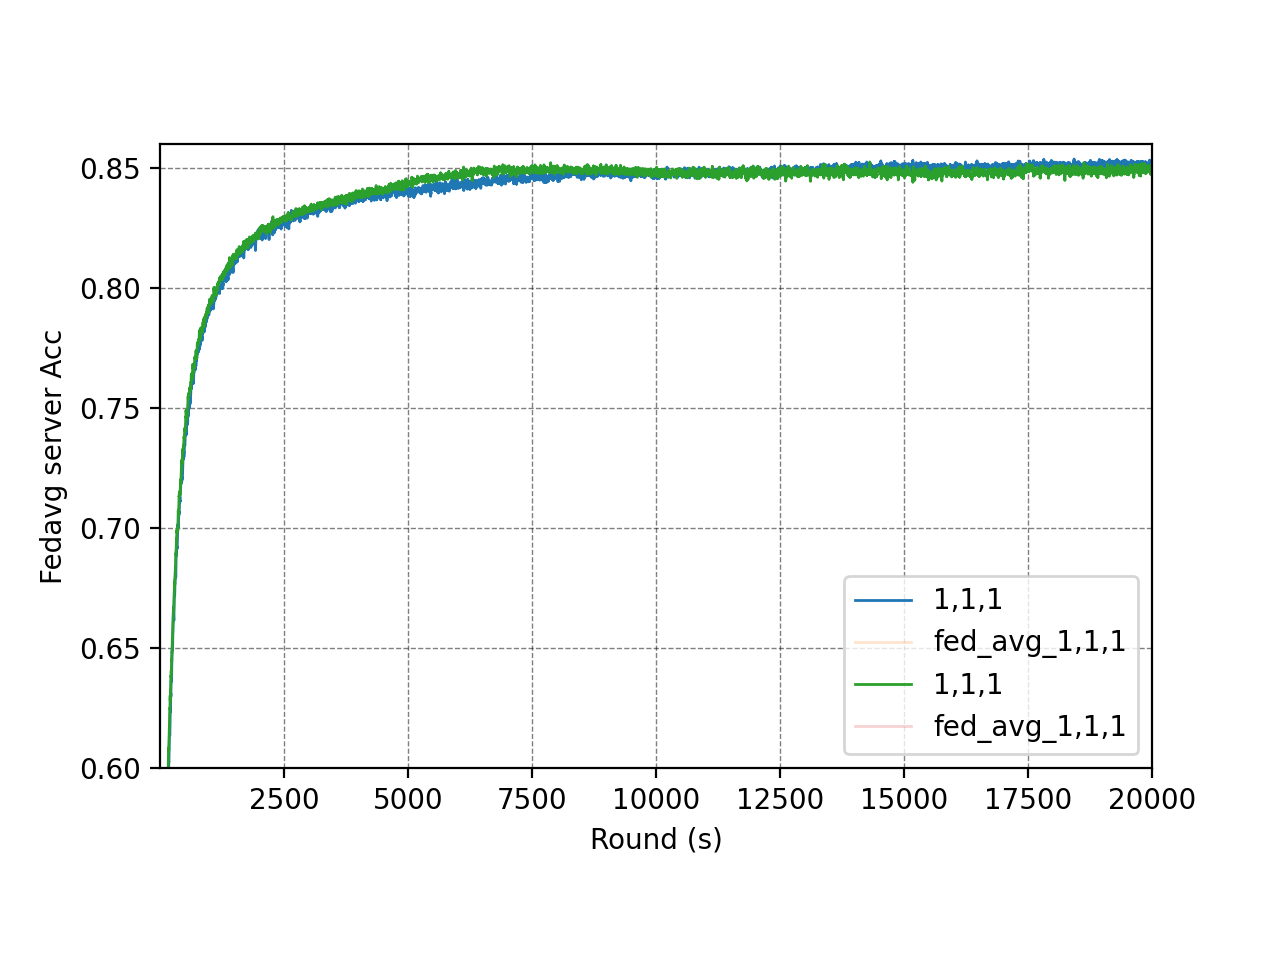

In [68]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


In [243]:
#to plot server acc

In [248]:
exp = ['Hetero_FL——[Hetero_fair_cuda_(1,5,1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg'
]


exp_legend = ['1,5,1',
]

In [262]:
# how do different densities affect the model acc
exp = [
    'Hetero_FL——[Hetero_fair_cuda_(1,5,9)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,93)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,96)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,5,98)_10000_coeff_round2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',

        'Hetero_FL——[Hetero_fair_cuda_(1,5,10)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg',
       'Hetero_FL——[Hetero_fair_cuda_(1,1,0.1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg', 
    'Hetero_FL——[Hetero_fair_cuda_(1,1,1)_10000_coeff_fed_avg_acc]unfair_1.0_1_no_increase_-1.0_sub_fed_avg'
]


exp_legend = [
              '1,5,9',
    '1,5,93','1,5,96','1,5,98',
    '1,5,10',
              '1,1,0.1',
              '1,1,1',
]

In [41]:
exp = [
#     'adaptive',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_1e-05_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.6]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_R2SP_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.2]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 1.0]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]n_-2.0_1_no_increase_-1.0_sub_fed_avg_g',
  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_fed_avg_w',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]u_1.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.4]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]u_-2.0_1_no_increase_-1.0_sub_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_fed_avg_g',
#  'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.8]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]n_1.0_1_no_increase_-1.0_sub_fed_avg_g',
 'Hetero_FL——[Hetero_fair_cuda]_[1, 0.5, 0.1]unfair_1.0_1_no_increase_-1.0_sub_fed_avg_sub_fed_avg']


exp_legend = [
#     [1,1,1],
 '[1, 0.5, 0.1]1e-05',
 '[1, 0.5, 0.6]',
#  '[1, 0.5, 0.1]R2SP_g',
    '[1, 0.5, 0.2]',
    '[1, 0.5, 1.0]',
    '[1, 0.5, 0.1]n_-2.0',
     '[1, 0.5, 0.1]w',
    '[1, 0.5, 0.1]u_1.0',
#     '[1, 0.5, 0.4]',
    '[1, 0.5, 0.1]u_-2.0',
#     '[1, 0.5, 0.1]_fed_avg',
#     '[1, 0.5, 0.8]',
    '[1, 0.5, 0.1]n_1',
    '[1, 0.5, 0.1]'
    ]





In [10]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


<IPython.core.display.Javascript object>

Skipping training results for FEMNIST, PIF_FEMNIST2_[1.0, 0.6, 0.3, 0.1]0.08__recover_polybuff_mask_fed_avg_Resdiual_niid__n__50_____esc. Client selection = False.
Skipping training results for FEMNIST, PIF_FEMNIST2_[1.0, 0.6, 0.3, 0.1]0.08__asyn__recover_polyfed_avg_Resdiual_niid__n__50_____esc. Client selection = False.


<IPython.core.display.Javascript object>


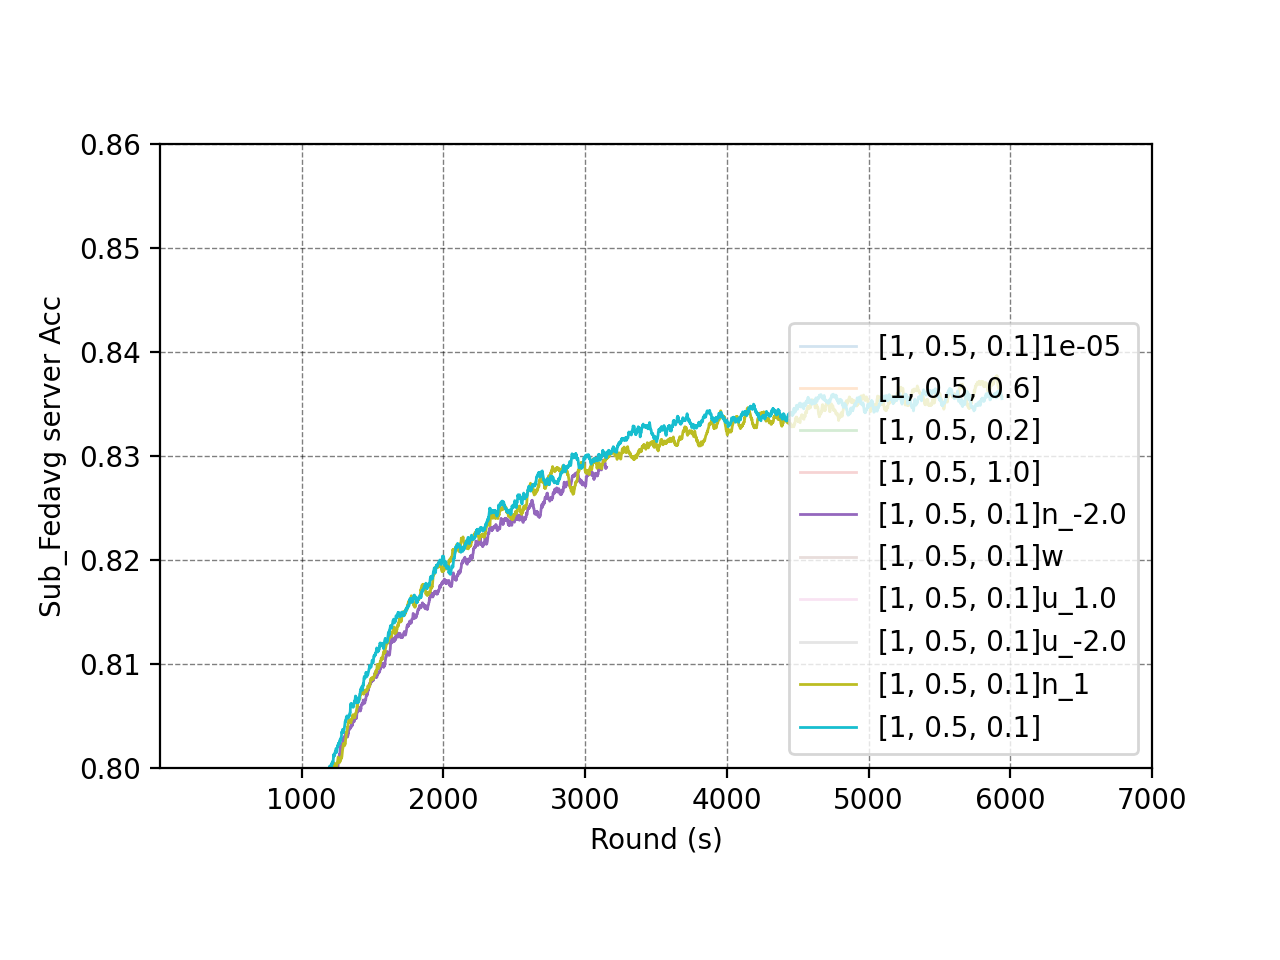

In [43]:
plt.figure()
n=50
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
#         avg_acc = load_fed_avg_acc(exp_name)
#         avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive_prune'or exp_name == 'adaptive_fine_tune':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
#         plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")

plt.xlabel(r"Round (s)")
plt.ylabel("Sub_Fedavg server Acc")
plt.xlim([1,7000])
plt.ylim([0.80,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)  # Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()


<IPython.core.display.Javascript object>


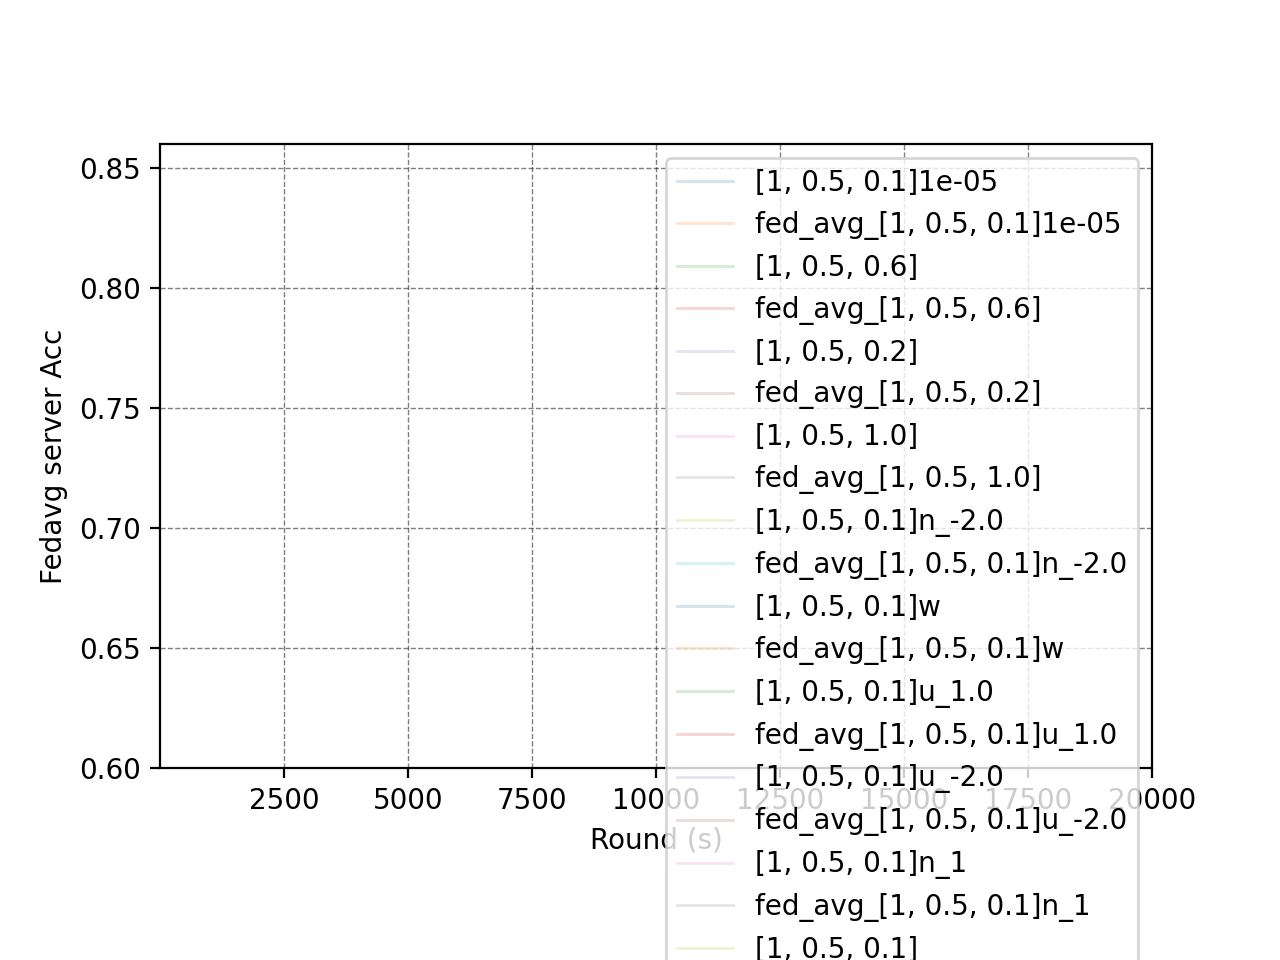

In [45]:
plt.figure()
n=10
for i in range(len(exp)):
    exp_name = exp[i]
    try:
        acc = load_acc(exp_name)
        acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
        avg_acc = load_fed_avg_acc(exp_name)
        avg_acc = np.convolve(avg_acc, np.ones((n,)) / n, mode='valid')
        time = range(0, len(acc))
        if exp_name == 'adaptive':
            time = range(0, len(acc) * 10, 10)
        plt.plot(time, acc, linewidth=1, label=exp_legend[i])
        plt.plot(time, avg_acc, linewidth=1, label='fed_avg_'+exp_legend[i])
        
    except FileNotFoundError:
        print(f"Skipping training results for {dataset_name}, {exp_name}. Client selection = {client_sel}.")
plt.xlabel(r"Round (s)")
plt.ylabel("Fedavg server Acc")
plt.xlim([1,20000])
plt.ylim([0.60,0.86])

plt.legend(exp_legend,frameon=False, loc="center right",fontsize='small',ncol=3)
        
        

# Get the current axes and legend
ax = plt.gca()
legend = ax.legend()


# Function to handle legend click event
def on_legend_click(event):
    legline = event.artist
    origline = legline._orig_artist
    vis = not origline.get_visible()
    origline.set_visible(vis)
    if vis:
        legline.set_alpha(1.0)
    else:
        legline.set_alpha(0.2)
    plt.draw()


# Connect the event handler to the legend
for legline, origline in zip(legend.get_lines(), ax.lines):
    legline.set_picker(True)
    legline._orig_artist = origline
    origline.set_visible(False)
    legline.set_alpha(0.2)# Set all lines to be initially hidden

plt.gcf().canvas.mpl_connect('pick_event', on_legend_click)



# 调整子图之间的间距和图形的大小
plt.subplots_adjust(top=0.85, bottom=0.2)
 
# Show the plot
plt.grid(linestyle="--", color='black', lw='0.5', alpha=0.5)
plt.show()
